# Proyek Machine Learning Dicoding: ***Movie Recommendation***

## *Personal Data*

*   ***Name***        : Fikri Dean Radityo
*   ***Username***    : fikridean11
*   ***Email***       : fikrideanradityo@gmail.com
*   **Linkedin**    : https://www.linkedin.com/in/fikridean/
*   ***University***  : Universitas Islam Negeri Syarif Hidayatullah Jakarta

## *Import Libraries*

In [ ]:
import gdown
import matplotlib.pyplot as plt
%matplotlib inline
import pandas as pd
import seaborn as sns
import numpy as np
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV

from imblearn.over_sampling import SMOTE
from sklearn.utils import resample

from tensorflow.keras.models import load_model
from tensorflow.keras.layers import TFSMLayer
import shutil, zipfile

## *Data Understanding*

### *Import Dataset*

Berikut dataset yang digunakan pada proyek ini

*   ***Dataset source***: https://www.kaggle.com/datasets/grouplens/movielens-20m-dataset/data
*   ***Dataset name***: MovieLens 20M Dataset

*Dataset* yang digunakan untuk pembangunan model machine learning ini adalah *dataset* "MovieLens 20M Dataset *dataset*" yang tersedia di situs web Kaggle pada [tautan](https://www.kaggle.com/datasets/grouplens/movielens-20m-dataset/data) ini. *Dataset* tersebut adalah *dataset* yang terdiri atas beberapa berkas antara lain:

- `tag.csv`
- `rating.csv`
- `movie.csv`
- `link.csv`
- `genome_scores.csv`
- `genome_tags.csv`

Dari berkas-berkas tersebut, berkas yang cocok dan akan digunakan pada proyek ini untuk membuat model dengan teknik content based filtering dan collaborative filtering adalah berkas `movie.csv` dan `rating.csv`.

Berikut ini adalah informasi lainnya mengenai *dataset* tersebut:

Variabel-variabel pada berkas `movie.csv` adalah sebagai berikut:
- `movieId`: *Identifier* yang digunakan untuk film
- `title`: Judul dari film yang ada pada berkas
- `genres`: Genre dari tiap film yang ada pada berkas

Variabel-variabel pada berkas `rating.csv` adalah sebagai berikut:
- `userId`: *Identifier* yang digunakan untuk user yang memberikan rating pada film
- `movieId`: *Identifier* yang digunakan untuk film
- `rating`: *Rating* yang diberikan oleh user untuk film
- `timestamp`: Waktu data berhasil dimasukkan ke dalam berkas

Mengambil kode tautan *google drive file sharing* yang akan digunakan untuk *download* *dataset* dan memasukkannya ke lokal.

In [ ]:
dataset_file_id = "1dU0Oazz0S8dT-Y3bxQoJ2D-V4rFUMAkh"

destination = "/content/movie.csv"

gdown.download(f"https://drive.google.com/uc?id={dataset_file_id}", destination, quiet=False)

Downloading...
From: https://drive.google.com/uc?id=1dU0Oazz0S8dT-Y3bxQoJ2D-V4rFUMAkh
To: /content/movie.csv
100%|██████████| 1.49M/1.49M [00:00<00:00, 149MB/s]


'/content/movie.csv'

In [ ]:
dataset_file_id = "19z9kWCobcD72Z2vI2gi6Cpx92_M5YZnL"

destination = "/content/rating.csv"

gdown.download(f"https://drive.google.com/uc?id={dataset_file_id}", destination, quiet=False)

Downloading...
From (original): https://drive.google.com/uc?id=19z9kWCobcD72Z2vI2gi6Cpx92_M5YZnL
From (redirected): https://drive.google.com/uc?id=19z9kWCobcD72Z2vI2gi6Cpx92_M5YZnL&confirm=t&uuid=b196345d-0204-4401-98d6-ce29a1debe43
To: /content/rating.csv
100%|██████████| 690M/690M [00:07<00:00, 87.6MB/s]


'/content/rating.csv'

Membuat *pandas dataframe* dari `movie.csv` dan `rating.csv` dan memasukkannya ke variabel.

In [ ]:
dataset_movie = "movie.csv"
dataset_rating = "rating.csv"

movie_df = pd.read_csv(dataset_movie)
rating_df = pd.read_csv(dataset_rating)

### *Exploratory Data Analysis*

> ***Exploratory Data Analysis*** (EDA) adalah tahap awal dalam mengeksplorasi data untuk menganalisis karakteristik, mengidentifikasi pola, menemukan anomali, dan memverifikasi asumsi-asumsi yang ada dalam data.

Mengambil panjang baris dan kolom serta nama-nama kolom yang ada di `movie_df`.

In [ ]:
print('movie_df row and column length:', movie_df.shape)
print('movie_df columns: ', movie_df.keys())

movie_df row and column length: (27278, 3)
movie_df columns:  Index(['movieId', 'title', 'genres'], dtype='object')


Berdasarkan *output* kode di atas didapatkan informasi mengenai `movie_df` sebagai berikut:

*   `movie_df` berisi jumlah baris dan kolom adalah 27278 baris dan 3 kolom.
*   Terdapat 3 kolom pada `movie_df` yaitu `movieId`, `title`, `genres`.

Mengambil informasi dari kolom-kolom yang ada di `movie_df`.

In [ ]:
print('movie_df columns information')
movie_df.info()

movie_df columns information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27278 entries, 0 to 27277
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   movieId  27278 non-null  int64 
 1   title    27278 non-null  object
 2   genres   27278 non-null  object
dtypes: int64(1), object(2)
memory usage: 639.5+ KB


Berdasarkan *output* kode diatas didapatkan informasi berikut:

*   Terdapat 2 kolom dengan tipe object, yaitu: `title` dan `genres`. Kolom ini merupakan categorical features (fitur non-numerik).
*   Terdapat 1 kolom numerik dengan tipe data int64, yaitu: `movieId`.

Mengambil informasi statistik dari `movie_df`.

In [ ]:
print('movie_df statistic information')
movie_df.describe()

movie_df statistic information


,movieId
count,27278.000000
mean,59855.480570
std,44429.314697
min,1.000000
25%,6931.250000
50%,68068.000000
75%,100293.250000
max,131262.000000


Fungsi describe() memberikan informasi statistik pada masing-masing kolom, antara lain:

*   **Count**  adalah jumlah sampel pada data.
*   **Mean** adalah nilai rata-rata.
*   **Std** adalah standar deviasi.
*   **Min** yaitu nilai minimum setiap kolom.
*   **25%** adalah kuartil pertama. Kuartil adalah nilai yang menandai batas interval dalam empat bagian sebaran yang sama.
*   **50%** adalah kuartil kedua, atau biasa juga disebut median (nilai tengah).
*   **75%** adalah kuartil ketiga.
*   **Max** adalah nilai maksimum.

Melihat contoh data dari `movie_df` dengan mengambil 5 baris pertama.

In [ ]:
print('movie_df top 5 rows example')
movie_df.head()

movie_df top 5 rows example


,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


Berdasarkan *output* kode diatas didapatkan informasi berikut:
- fitur `movieId` dan `title` sudah sesuai dan dapat lanjut ke tahap berikutnya.
- fitur `genres` berisi lebih dari satu genre untuk tiap film dan perlu diproses dengan mengambil genre utama dari tiap film.

Melakukan split terhadap kolom *genres* pada `movie_df`.

In [ ]:
movie_df['genres'] = movie_df['genres'].str.split('|').str[0]

Kode diatas bertujuan untuk mengambil genre utama dari tiap film dan menjadikan kolom genre hanya berisi satu genre dengan melakukan split terhadap *value* dari tiap genre.

Melihat contoh data dari `movie_df` dengan mengambil 5 baris pertama.

In [ ]:
print('movie_df top 5 rows')
movie_df.head()

movie_df top 5 rows


,movieId,title,genres
0,1,Toy Story (1995),Adventure
1,2,Jumanji (1995),Adventure
2,3,Grumpier Old Men (1995),Comedy
3,4,Waiting to Exhale (1995),Comedy
4,5,Father of the Bride Part II (1995),Comedy


Melihat jumlah data `movieId` yang unik yang ada di `movie_df`.


In [ ]:
print('Num of unique movieId: ', len(movie_df['movieId'].unique()))

Num of unique movieId:  27278


Kode diatas bertujuan untuk mengecek apakah kolom `movieId` yang ada pada `movie_df` unik semua dan tidak ada yang sama. Bisa dilihat terdapat 27278 data unik yang dimana sama dengan jumlah data, yang dimana berarti seluruh data `movieId` yang ada pada `movie_df` merupakan data unik.

Melihat jumlah data genre dari `movie_df` dan menampilkannya.


In [ ]:
print('Num of unique genres:', len(movie_df['genres'].unique()))
print('List of unique genres:', movie_df['genres'].unique())

Num of unique genres: 20
List of unique genres: ['Adventure' 'Comedy' 'Action' 'Drama' 'Crime' 'Children' 'Mystery'
 'Documentary' 'Animation' 'Thriller' 'Horror' 'Fantasy' 'Western'
 'Film-Noir' 'Romance' 'War' 'Sci-Fi' 'Musical' 'IMAX'
 '(no genres listed)']


Dari *output* kode diatas, dapat dilihat terdapat 20 genre yang unik dan terdiri atas:
- Adventure
- Comedy
- Action
- Drama
- Crime
- Children
- Mystery
- Documentary
- Animation
- Thriller
- Horror
- Fantasy
- Western
- Film-Noir
- Romance
- War
- Sci-Fi
- Musical
- IMAX
- (no genres listed)

Melihat jumlah data dari setiap genre yang ada di kolom `genres` yang ada di `movie_df`.

In [ ]:
movie_df['genres'].value_counts()

,count
genres,
Drama,7875
Comedy,6793
Action,3520
Documentary,2247
Crime,1617
Horror,1380
Adventure,1357
Animation,571
Children,414


Dari *output* kode diatas, dapat dilihat bahwa terdapat *outlier* pada `movie_df` yang dimana nantinya akan dihapus.

Mengambil panjang baris dan kolom serta nama-nama kolom yang ada di `rating_df`.

In [ ]:
print('rating_df row and column length:', rating_df.shape)
print('rating_df columns: ', rating_df.keys())

rating_df row and column length: (20000263, 4)
rating_df columns:  Index(['userId', 'movieId', 'rating', 'timestamp'], dtype='object')


Berdasarkan *output* kode di atas didapatkan informasi berikut:

*   Jumlah baris dan kolom adalah 20000263 baris dan 4 kolom.
*   Terdapat 9 kolom fitur yaitu `userId`, `movieId`, `rating`, `timestamp`.

Mengambil informasi dari kolom-kolom yang ada di `rating_df`.

In [ ]:
print('rating_df columns information')
rating_df.info()

rating_df columns information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000263 entries, 0 to 20000262
Data columns (total 4 columns):
 #   Column     Dtype  
---  ------     -----  
 0   userId     int64  
 1   movieId    int64  
 2   rating     float64
 3   timestamp  object 
dtypes: float64(1), int64(2), object(1)
memory usage: 610.4+ MB


Berdasarkan *output* kode diatas didapatkan informasi berikut:

*   Terdapat 1 kolom dengan tipe *object*, yaitu: `timestamp`. Kolom ini merupakan categorical features (fitur non-numerik).
*   Terdapat 2 kolom numerik dengan tipe data *int64*, yaitu: `userId` dan `movieId`.
*   Terdapat 1 kolom numerik dengan tipe data *float64*, yaitu `rating`.

Mengambil informasi statistik dari `rating_df`.

In [ ]:
print('rating_df statistic information')
rating_df.describe()

rating_df statistic information


,userId,movieId,rating
count,2.000026e+07,2.000026e+07,2.000026e+07
mean,6.904587e+04,9.041567e+03,3.525529e+00
std,4.003863e+04,1.978948e+04,1.051989e+00
min,1.000000e+00,1.000000e+00,5.000000e-01
25%,3.439500e+04,9.020000e+02,3.000000e+00
50%,6.914100e+04,2.167000e+03,3.500000e+00
75%,1.036370e+05,4.770000e+03,4.000000e+00
max,1.384930e+05,1.312620e+05,5.000000e+00


Fungsi describe() memberikan informasi statistik pada masing-masing kolom, antara lain:

*   **Count**  adalah jumlah sampel pada data.
*   **Mean** adalah nilai rata-rata.
*   **Std** adalah standar deviasi.
*   **Min** yaitu nilai minimum setiap kolom.
*   **25%** adalah kuartil pertama. Kuartil adalah nilai yang menandai batas interval dalam empat bagian sebaran yang sama.
*   **50%** adalah kuartil kedua, atau biasa juga disebut median (nilai tengah).
*   **75%** adalah kuartil ketiga.
*   **Max** adalah nilai maksimum.

Melihat contoh data dari `rating_df` dengan mengambil 5 baris pertama.

In [ ]:
print('rating_df top 5 rows example')
rating_df.head()

rating_df top 5 rows example


,userId,movieId,rating,timestamp
0,1,2,3.5,2005-04-02 23:53:47
1,1,29,3.5,2005-04-02 23:31:16
2,1,32,3.5,2005-04-02 23:33:39
3,1,47,3.5,2005-04-02 23:32:07
4,1,50,3.5,2005-04-02 23:29:40


Melihat jumlah data user yang unik yang ada di `rating_df`.

In [ ]:
print('Num of unique users:', len(rating_df['userId'].unique()))

Num of unique users: 138493


Berdasarkan *output* kode diatas, terdapat sebanyak 138493 data *user* yang unik pada `rating_df`.

Melihat jumlah data `movieId` yang unik yang ada di `rating_df`.

In [ ]:
print('Num of unique movie:', len(rating_df['movieId'].unique()))

Num of unique movie: 26744


Berdasarkan *output* kode diatas, terdapat sebanyak 138493 data film yang unik pada `rating_df`.

Melihat jumlah data yang memiliki value `null` pada `movie_df`.

In [ ]:
missing_values = movie_df.isnull().sum()
missing_values

,0
movieId,0
title,0
genres,0


Berdasarkan *output* kode diatas, tidak terdapat satupun data *null* pada `movie_df`.

Melihat jumlah data yang memiliki value `null` pada `rating_df`.

In [ ]:
missing_values = rating_df.isnull().sum()
missing_values

,0
userId,0
movieId,0
rating,0
timestamp,0


Berdasarkan *output* kode diatas, tidak terdapat satupun data *null* pada `rating_df`.

In [ ]:
print(movie_df.duplicated().any())
print(movie_df[movie_df.duplicated()])

False
Empty DataFrame
Columns: [movieId, title, genres]
Index: []


Berdasarkan *output* kode diatas, tidak terdapat satupun data duplikat pada `movie_df`.

Melihat apakah terdapat data yang duplikat pada `rating_df`.

In [ ]:
print(rating_df.duplicated().any())
print(rating_df[rating_df.duplicated()])

False
Empty DataFrame
Columns: [userId, movieId, rating, timestamp]
Index: []


Melihat apakah terdapat data yang memiliki *value* `NaN` pada `movie_df`.

In [ ]:
print(movie_df.isna().any().any())
print(movie_df[movie_df.isna().any(axis=1)])

False
Empty DataFrame
Columns: [movieId, title, genres]
Index: []


Berdasarkan *output* kode diatas, tidak terdapat satupun data NaN pada `movie_df`.

Melihat apakah terdapat data yang memiliki *value* `NaN` pada `rating_df`.

In [ ]:
print(rating_df.isna().any().any())
print(rating_df[rating_df.isna().any(axis=1)])

False
Empty DataFrame
Columns: [userId, movieId, rating, timestamp]
Index: []


Berdasarkan *output* kode diatas, tidak terdapat satupun data NaN pada `rating_df`.

### *Data Visualization*

#### *Univariate Analysis*

> *Univariate analysis* adalah jenis analisis yang berfokus pada satu variabel (*feature*) dalam satu waktu. Tujuan utamanya adalah untuk memahami distribusi, karakteristik, dan pola dari variabel tersebut.

Membuat fungsi untuk menghitung jumlah dan persentase data dari masing-masing data.

In [ ]:
def CountAndPlot(df, feature):
  count = df[feature].value_counts()
  percent = 100*df[feature].value_counts(normalize=True)
  samples = pd.DataFrame({'Sample Count':count, 'Percentage':percent.round(1)})
  print(samples)
  count.plot(kind='bar', title=feature)

Membuat *graph* untuk kolom genres pada `movie_df`.

                    Sample Count  Percentage
genres                                      
Drama                       7875        28.9
Comedy                      6793        24.9
Action                      3520        12.9
Documentary                 2247         8.2
Crime                       1617         5.9
Horror                      1380         5.1
Adventure                   1357         5.0
Animation                    571         2.1
Children                     414         1.5
Thriller                     279         1.0
(no genres listed)           246         0.9
Western                      215         0.8
Sci-Fi                       168         0.6
Mystery                      146         0.5
Romance                      145         0.5
Fantasy                      137         0.5
Musical                       94         0.3
Film-Noir                     38         0.1
War                           35         0.1
IMAX                           1         0.0


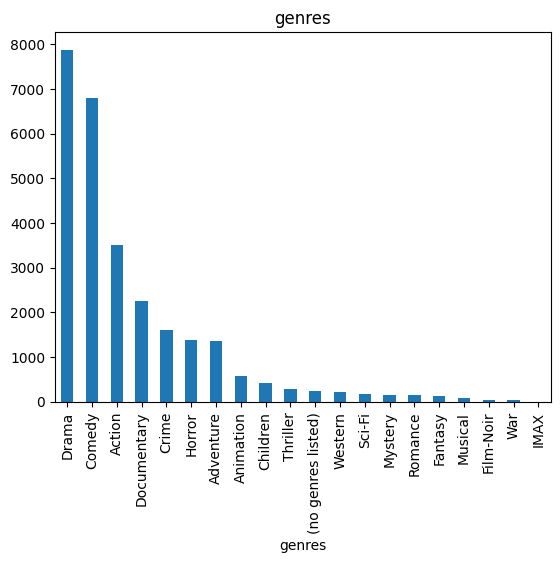

In [ ]:
CountAndPlot(movie_df, 'genres')

Berdasarkan grafik diatas, dapat dilihat bahwa jumlah data genre drama mendominasi `movie_df` yang dimana disusul oleh genre `comedy` dan `action`.

        Sample Count  Percentage
rating                          
4.0          5561926        27.8
3.0          4291193        21.5
5.0          2898660        14.5
3.5          2200156        11.0
4.5          1534824         7.7
2.0          1430997         7.2
2.5           883398         4.4
1.0           680732         3.4
1.5           279252         1.4
0.5           239125         1.2


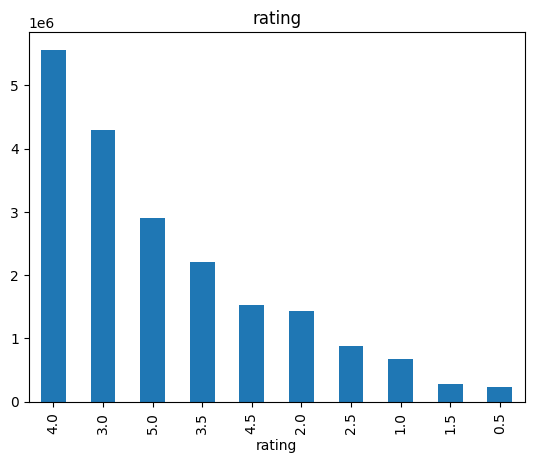

In [ ]:
CountAndPlot(rating_df, 'rating')

Berdasarkan grafik diatas, dapat dilihat bahwa mayoritas *user* memberikan rating ke film adalah sebesar `4.0`.

### *Data Preperation*

#### *Data Cleaning*

> **Penjelasan**: *Data Cleaning* adalah proses untuk memperbaiki atau menghapus data yang salah, rusak, tidak sesuai format, duplikat, atau tidak lengkap dalam sebuah *dataset*. Ketika berbagai sumber data digabungkan, risiko terjadinya duplikasi atau pelabelan yang salah meningkat secara signifikan.

> **Alasan**: Proses *Data Cleaning* penting dilakukan untuk memeriksa, memperbaiki, dan memastikan bahwa data yang digunakan siap diproses serta bebas dari potensi kesalahan.

##### *Removal Duplicates and NaN Data*

> **Penjelasan**: Menghapus data duplikat bertujuan memastikan dataset menjadi unik dan bebas dari baris yang redundan. Duplikasi dapat terjadi karena kesalahan dalam pengumpulan data, penggabungan dataset, atau duplikasi yang tidak disengaja.

> **Alasan**: Proses ini diperlukan untuk membersihkan data yang dapat memicu kesalahan, seperti nilai *NaN*, dan menghilangkan data yang berpotensi menurunkan performa, seperti data duplikat.

Membersihkan `movie_df` dan `rating_df` dari data yang duplikat dan data yang memiliki *value* `NaN`. Kemudian memasukkan hasil dari kedua proses tersebut ke `clean_movie_df` dan `clean_movie_df`.

In [ ]:
clean_movie_df = movie_df.drop_duplicates().dropna()
clean_rating_df = rating_df.drop_duplicates().dropna()

In [ ]:
clean_movie_df.head()

,movieId,title,genres
0,1,Toy Story (1995),Adventure
1,2,Jumanji (1995),Adventure
2,3,Grumpier Old Men (1995),Comedy
3,4,Waiting to Exhale (1995),Comedy
4,5,Father of the Bride Part II (1995),Comedy


In [ ]:
clean_rating_df.head()

,userId,movieId,rating,timestamp
0,1,2,3.5,2005-04-02 23:53:47
1,1,29,3.5,2005-04-02 23:31:16
2,1,32,3.5,2005-04-02 23:33:39
3,1,47,3.5,2005-04-02 23:32:07
4,1,50,3.5,2005-04-02 23:29:40


##### *Removal Irrelevant Columns*

> **Penjelasan**: Menghapus data yang tidak relevan dan tidak diperlukan pada proyek.

> **Alasan**: Proses ini diperlukan untuk membersihkan data dari data yang tidak relevan dan tidak diperlukan. Kemudian selanjutnya memastikan bahwa `movieId` yang ada di `rating_df` ada di `movie_df` juga agar sesuai ketika data diproses pada tahap-tahap selanjutnya.

Jika dilihat dari `plot` pada tahap *data understanding*, pada `movie_df` terdapat satu genre yang dimana perlu untuk dihapus karena tidak diperlukan untuk pengembangan model, yaitu genre `(no genres listed)`. Selain itu, pada `rating_df` terdapat kolom `timestamp` yang dimana tidak diperlukan pada pengembangan model.

Menghapus genre film yang tidak relevan yaitu '(no genres listed)' dari `clean_movie_df`.

In [ ]:
clean_movie_df = clean_movie_df.loc[clean_movie_df['genres'] != '(no genres listed)']
clean_movie_df['genres'].value_counts()

,count
genres,
Drama,7875
Comedy,6793
Action,3520
Documentary,2247
Crime,1617
Horror,1380
Adventure,1357
Animation,571
Children,414


Menghapus kolom `timestamp` pada `clean_rating_df` yang dimana tidak diperlukan untuk pengembangan model.

In [ ]:
clean_rating_df = clean_rating_df.drop(columns=['timestamp'])
clean_rating_df.head()

,userId,movieId,rating
0,1,2,3.5
1,1,29,3.5
2,1,32,3.5
3,1,47,3.5
4,1,50,3.5


Kemudian selanjutnya memastikan bahwa `movieId` yang ada di `rating_df` terdaftar pada `movie_df` juga agar sesuai ketika data diproses pada tahap-tahap selanjutnya.

In [ ]:
movieIds = clean_rating_df['movieId'].unique()
print('Total: ', len(movieIds))
movieIds

Total:  26744


array([     2,     29,     32, ..., 121021, 110167, 110510])

In [ ]:
len(clean_rating_df)

20000263

In [ ]:
clean_rating_df = clean_rating_df[clean_rating_df['movieId'].isin(movieIds)]
len(clean_rating_df)

20000263

##### *Handle Imbalance Data*

> **Penjelasan**: Memeriksa dan menghapus data untuk mengatasi masalah ketidakseimbangan

> **Alasan**: Proses ini diperlukan untuk membersihkan data dari data yang terlalu sedikit jumlahnya dan tidak seimbang terhadap jumlah data lainnya

Menghapus data genre *IMAX* karena terlalu sedikit data yang ada pada `clean_movie_df`.

In [ ]:
clean_movie_df = clean_movie_df[clean_movie_df['genres'] != 'IMAX']
print('IMAX Genres Count : ', len(clean_movie_df[clean_movie_df['genres'] == 'IMAX']))
print()
print(clean_movie_df['genres'].value_counts())

IMAX Genres Count :  0

genres
Drama          7875
Comedy         6793
Action         3520
Documentary    2247
Crime          1617
Horror         1380
Adventure      1357
Animation       571
Children        414
Thriller        279
Western         215
Sci-Fi          168
Mystery         146
Romance         145
Fantasy         137
Musical          94
Film-Noir        38
War              35
Name: count, dtype: int64


Melakukan *grouping* untuk setiap `movieId` terhadap seluruh data *rating* yang ada.

In [ ]:
grouped_ratings = clean_rating_df.groupby('movieId')
grouped_ratings.groups

{1: [236, 517, 817, 922, 960, 1464, 1500, 1562, 1854, 2061, 2302, 2435, 2537, 3534, 3903, 4305, 4794, 5194, 5400, 6343, 7000, 7477, 7627, 8676, 8724, 9031, 9494, 9621, 10319, 10425, 10874, 10993, 12452, 12511, 12654, 13045, 13112, 13174, 14284, 14635, 14996, 15154, 15441, 15701, 16467, 16818, 17403, 17556, 17652, 18144, 18523, 18563, 18718, 18740, 19180, 19783, 19846, 22329, 22355, 22533, 23040, 23284, 23514, 23604, 24196, 24303, 24376, 25017, 25226, 25362, 25435, 25868, 27156, 27482, 27796, 28095, 28502, 29007, 29133, 29246, 29381, 29579, 29842, 31943, 32879, 33439, 33491, 33692, 34089, 34306, 34490, 35290, 35312, 35866, 36105, 36852, 37045, 37163, 37452, 38107, ...], 2: [0, 451, 1501, 3326, 3904, 5401, 9210, 9622, 13175, 14378, 14408, 14636, 15028, 15097, 15155, 15702, 16132, 17653, 18459, 19290, 19847, 22139, 22794, 22864, 23285, 23978, 28096, 29008, 29247, 29580, 31871, 31944, 32752, 33440, 34491, 35442, 37453, 38108, 38432, 38478, 40150, 41429, 42633, 42722, 43071, 44241, 44790, 4

Melakukan *undersampling* dengan masing-masing `movie_id` akan dikaitkan dengan maksimal tiga `userId`.

In [ ]:
target_ratings = 3

clean_rating_df = pd.concat(
    [
        group.sample(n=target_ratings, random_state=42) if len(group) > target_ratings else
        resample(group, replace=True, n_samples=target_ratings, random_state=42)
        for _, group in grouped_ratings
    ]
)

clean_rating_df

,userId,movieId,rating
4834169,33218,1,5.0
1716733,11586,1,3.0
7170935,49444,1,4.0
2461714,16670,2,2.0
12736079,88015,2,3.5
...,...,...,...
9459645,65409,131260,3.0
9459645,65409,131260,3.0
19227262,133047,131262,4.0
19227262,133047,131262,4.0


#### *Text Processing*

> **Penjelasan**: Proses mengidentifikasi dan memperbaiki atau menghapus data yang salah, tidak konsisten, atau tidak relevan dalam dataset.

> **Alasan**: Proses ini diperlukan agar semua data konsisten dan tidak ada data yang dalam format berbeda

In [ ]:
clean_movie_df['genres'] = clean_movie_df['genres'].replace({'Film-Noir': 'Filmnoir', 'Sci-Fi': 'Scifi'})
print('IMAX Genres Count : ', len(clean_movie_df[clean_movie_df['genres'] == 'Filmnoir']))
print('IMAX Genres Count : ', len(clean_movie_df[clean_movie_df['genres'] == 'Scifi']))

print()

print('Example movie with genre Filmnoir')
print(clean_movie_df[clean_movie_df['genres'] == 'Filmnoir'].head())

print()

print('Example movie with genre Scifi')
print(clean_movie_df[clean_movie_df['genres'] == 'Scifi'].head())

IMAX Genres Count :  38
IMAX Genres Count :  168

Example movie with genre Filmnoir
      movieId                       title    genres
317       320               Suture (1993)  Filmnoir
733       746        Force of Evil (1948)  Filmnoir
896       913  Maltese Falcon, The (1941)  Filmnoir
913       930            Notorious (1946)  Filmnoir
1130     1153             Raw Deal (1948)  Filmnoir

Example movie with genre Scifi
      movieId                                  title genres
864       880       Island of Dr. Moreau, The (1996)  Scifi
1708     1779                          Sphere (1998)  Scifi
2226     2311  2010: The Year We Make Contact (1984)  Scifi
2441     2526                          Meteor (1979)  Scifi
2493     2578     Sticky Fingers of Time, The (1997)  Scifi


<ipython-input-38-d9236ad69a26>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  clean_movie_df['genres'] = clean_movie_df['genres'].replace({'Film-Noir': 'Filmnoir', 'Sci-Fi': 'Scifi'})


In [ ]:
clean_movie_df.to_csv('clean_movie_df.csv', index=False)

#### *Data Transformation*

> **Penjelasan**: *Data transformation* adalah proses mengubah data mentah ke dalam format yang lebih cocok untuk analisis atau pelatihan model. Transformasi ini melibatkan berbagai teknik, seperti normalisasi, standardisasi, encoding, dan scaling, untuk memastikan data berada dalam skala atau bentuk yang sesuai dengan kebutuhan algoritma machine learning.

> **Alasan**: Proses ini diperlukan untuk meningkatkan kualitas data sehingga model dapat belajar secara lebih efektif seperti dalam pengembangan model *sentiment analysis*.


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf = TfidfVectorizer()

In [ ]:
tfidf_matrix = tfidf.fit_transform(movie_df['genres'])
tfidf_matrix.shape

(27278, 24)

In [ ]:
tfidf_matrix.todense()

matrix([[0., 1., 0., ..., 0., 0., 0.],
        [0., 1., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 1., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 1., 0., ..., 0., 0., 0.]])

In [ ]:
df = pd.DataFrame(
    tfidf_matrix.todense(),
    columns=tfidf.get_feature_names_out(),
    index=movie_df.title
)

sampled_df = df.sample(df.shape[1], axis=1).sample(df.shape[0], axis=0)
sampled_df

,western,thriller,action,fantasy,fi,genres,horror,drama,comedy,imax,...,noir,adventure,romance,documentary,mystery,sci,children,film,war,no
title,,,,,,,,,,,,,,,,,,,,,
Blablablá (1975),0.0,0.0,0.0,0.0,0.0,0.57735,0.0,0.0,0.0,0.0,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.57735
Sunes sommar (1993),0.0,0.0,0.0,0.0,0.0,0.00000,0.0,0.0,1.0,0.0,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.00000
Killjoy Goes to Hell (2012),0.0,0.0,0.0,0.0,0.0,0.00000,0.0,0.0,1.0,0.0,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.00000
"Pom Poko (a.k.a. Raccoon War, The) (Heisei tanuki gassen pompoko) (1994)",0.0,0.0,0.0,0.0,0.0,0.00000,0.0,0.0,0.0,0.0,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.00000
"Friends of Eddie Coyle, The (1973)",0.0,0.0,0.0,0.0,0.0,0.00000,0.0,0.0,0.0,0.0,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.00000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
"Great White Silence, The (1924)",0.0,0.0,0.0,0.0,0.0,0.00000,0.0,0.0,0.0,0.0,...,0.000000,0.0,0.0,1.0,0.0,0.0,0.0,0.000000,0.0,0.00000
Kiss Me Deadly (1955),0.0,0.0,0.0,0.0,0.0,0.00000,0.0,0.0,0.0,0.0,...,0.707107,0.0,0.0,0.0,0.0,0.0,0.0,0.707107,0.0,0.00000
Jungle Book (1942),0.0,0.0,0.0,0.0,0.0,0.00000,0.0,0.0,0.0,0.0,...,0.000000,1.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.00000


#### *Calculating Cosine Similarity*

> **Penjelasan**: *Cosine similarity* adalah metode yang digunakan untuk mengukur tingkat kesamaan antara dua vektor dalam ruang multidimensi berdasarkan sudut di antara mereka. Nilai cosine similarity berkisar antara -1 dan 1, di mana nilai 1 menunjukkan kesamaan sempurna, 0 menunjukkan tidak ada kesamaan, dan -1 menunjukkan arah yang sepenuhnya berlawanan.

> **Alasan**: Proses ini harus dilakukan karena kemampuannya untuk mengukur kesamaan antara dokumen atau data yang akan digunakan pada model.


In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

cosine_sim = cosine_similarity(tfidf_matrix)
cosine_sim

array([[1., 1., 0., ..., 1., 0., 1.],
       [1., 1., 0., ..., 1., 0., 1.],
       [0., 0., 1., ..., 0., 0., 0.],
       ...,
       [1., 1., 0., ..., 1., 0., 1.],
       [0., 0., 0., ..., 0., 1., 0.],
       [1., 1., 0., ..., 1., 0., 1.]])

In [ ]:
cosine_sim_df = pd.DataFrame(cosine_sim, index=movie_df.title, columns=movie_df.title)
print('Shape:', cosine_sim_df.shape)

cosine_sim_df.sample(5, axis=1).sample(10, axis=0)

Shape: (27278, 27278)


title,Orchestra Wives (1942),"Prey, The (La proie) (2011)",Ollie Hopnoodle's Haven of Bliss (1988),Midnight Man (1997),Bat*21 (1988)
title,,,,,
Naked Blood: Megyaku (Nekeddo burâddo: Megyaku) (1996),0.0,0.0,0.0,0.0,0.0
Animals are Beautiful People (1974),0.0,0.0,0.0,0.0,0.0
London - The Modern Babylon (2012),0.0,0.0,0.0,0.0,0.0
"Stranger Among Us, A (1992)",0.0,0.0,0.0,0.0,0.0
Bloodhounds of Broadway (1989),0.0,0.0,0.0,0.0,0.0
"Crazies, The (2010)",0.0,1.0,0.0,1.0,0.0
"Morning After, The (1986)",0.0,0.0,0.0,0.0,1.0
Slacker (1991),0.0,0.0,0.0,0.0,0.0
Welcome to Mooseport (2004),0.0,0.0,0.0,0.0,0.0


#### *Data Encoding*

> **Penjelasan**: *Data encoding* adalah proses mengubah data menjadi format numerik.

> **Alasan**: Sebelumnya *value* dari userId dan movieId tidak beurutan (0, 1, 2, dst) sehingga proses ini proses ini harus dilakukan untuk mengubah data menjadi numerik yang berurutan (*index*) agar model dapat dengan mudah diproses.

In [ ]:
user_ids = clean_rating_df['userId'].unique().tolist()
print('list userId: ', user_ids)

user_to_user_encoded = {x: i for i, x in enumerate(user_ids)}
print('encoded userID : ', user_to_user_encoded)

user_encoded_to_user = {i: x for i, x in enumerate(user_ids)}
print('encoded angka ke userID: ', user_encoded_to_user)

list userId:  [33218, 11586, 49444, 16670, 88015, 85437, 131155, 128109, 40111, 137949, 97458, 64024, 96522, 46046, 94231, 42859, 64111, 45461, 68288, 67199, 3285, 77240, 89300, 31659, 5010, 35625, 67197, 13488, 102898, 40124, 64554, 63530, 17164, 51331, 132095, 57844, 85269, 106783, 40105, 46222, 26551, 28975, 42204, 58818, 42470, 123514, 79559, 121997, 41536, 104135, 87933, 69577, 2083, 88003, 40020, 77008, 108473, 20132, 25423, 69327, 92715, 97598, 32314, 36748, 62589, 98926, 34648, 73156, 48940, 46963, 131819, 90951, 55554, 79351, 21012, 137640, 97220, 64863, 54369, 110934, 79605, 14359, 120995, 74788, 122452, 119071, 42141, 134369, 84927, 132984, 68110, 16157, 76941, 36442, 60056, 101818, 110812, 127141, 1638, 26403, 122437, 72202, 89137, 83828, 123671, 62771, 36098, 5291, 128653, 587, 116113, 136919, 18611, 33058, 83705, 105561, 42304, 7051, 59555, 110551, 45333, 130304, 83794, 96703, 87690, 105704, 2734, 10005, 120970, 48724, 87980, 3746, 4495, 53313, 9742, 24964, 131144, 107802

In [ ]:
movie_ids = clean_rating_df['movieId'].unique().tolist()
print('list movieId: ', movie_ids)

movie_to_movie_encoded = {x: i for i, x in enumerate(movie_ids)}
print('encoded movieId : ', movie_to_movie_encoded)

movie_encoded_to_movie = {i: x for i, x in enumerate(movie_ids)}
print('encoded angka ke movieId: ', movie_encoded_to_movie)

list movieId:  [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184, 185, 186, 187, 188, 189, 190, 191, 192, 193, 194, 195, 196, 197, 198, 199, 200, 201, 202, 203, 204, 205, 206, 207, 208, 209, 210, 211, 212, 213, 214, 215, 216, 217, 218, 219, 2

In [ ]:
clean_rating_df['user'] = clean_rating_df['userId'].map(user_to_user_encoded)

In [ ]:
clean_rating_df['movie'] = clean_rating_df['movieId'].map(movie_to_movie_encoded)

In [ ]:
clean_rating_df

,userId,movieId,rating,user,movie
4834169,33218,1,5.0,0,0
1716733,11586,1,3.0,1,0
7170935,49444,1,4.0,2,0
2461714,16670,2,2.0,3,1
12736079,88015,2,3.5,4,1
...,...,...,...,...,...
9459645,65409,131260,3.0,14538,26742
9459645,65409,131260,3.0,14538,26742
19227262,133047,131262,4.0,19585,26743
19227262,133047,131262,4.0,19585,26743


In [ ]:
num_users = len(user_to_user_encoded)
print(num_users)

num_movie = len(movie_encoded_to_movie)
print(num_movie)

clean_rating_df['rating'] = clean_rating_df['rating'].values.astype(np.float32)
min_rating = min(clean_rating_df['rating'])
max_rating = max(clean_rating_df['rating'])

print('Number of User: {}, Number of Movie: {}, Min Rating: {}, Max Rating: {}'.format(
    num_users, num_movie, min_rating, max_rating
))

20404
26744
Number of User: 20404, Number of Movie: 26744, Min Rating: 0.5, Max Rating: 5.0


#### *Train Test Split*

> **Penjelasan**: *Train-test split* adalah metode sederhana untuk mengukur kinerja algoritma machine learning dalam prediksi dengan membandingkan hasil model yang dibuat dengan data yang belum pernah dilihat sebelumnya.

> **Alasan**: Proses ini dilakukan dengan tujuan untuk melakukan evaluasi terhadap model yang akan dibuat dengan mengukur seberapa baik model dapat memprediksi data yang belum pernah dilihat (data yang tidak dimasukkan ke data latih melainkan ke data *test*).

In [ ]:
clean_rating_df = clean_rating_df.sample(frac=1, random_state=42)
clean_rating_df

x = clean_rating_df[['user', 'movie']].values
y = clean_rating_df['rating'].apply(lambda x: (x - min_rating) / (max_rating - min_rating)).values

train_indices = int(0.8 * clean_rating_df.shape[0])
x_train, x_val, y_train, y_val = (
    x[:train_indices],
    x[train_indices:],
    y[:train_indices],
    y[train_indices:]
)

print(x, y)

[[ 1154 21338]
 [15268  9984]
 [  991  4567]
 ...
 [ 4449 25606]
 [  831   286]
 [ 8479  5265]] [0.66666667 1.         0.55555556 ... 0.44444444 0.55555556 0.33333333]


### *Modelling*

Pada proyek ini, terdapat dua model sistem rekomendasi yang dibuat yaitu model sistem rekomendasi dengan teknik *Content Based Filtering* dan dengan teknik *Collaborative Filtering*.

1. *Content Based Filtering*

    *Content-Based Filtering* merekomendasikan sesuatu (*item*) kepada pengguna berdasarkan apa yang sudah mereka sukai sebelumnya. Teknik ini fokus pada karakteristik atau fitur dari *item* tersebut.

  Kelebihan:
    - Personal: Rekomendasinya benar-benar sesuai dengan minat pengguna.
    - Mudah dikembangkan: Jika terdapat informasi baru berkaitan dengan *item*, sistem bisa langsung diperbarui.
    - Tidak perlu data pengguna lain: Hanya memerlukan data pengguna itu sendiri.

  Kekurangan:
    - Pilihan terbatas: Hanya bisa merekomendasikan item yang mirip dengan yang sudah disukai, jadi kurang variasi.
    - Masalah untuk item baru: Jika *item* belum punya deskripsi lengkap, sulit untuk direkomendasikan.


2. *Collaborative Filtering*

    *Collaborative Filtering* merekomendasikan sesuatu (*item*) berdasarkan kesukaan orang lain yang memiliki preferensi mirip dengan pengguna.

  Kelebihan:
    - Variasi lebih besar: Teknik ini daoat merekomendasikan hal-hal yang belum pernah dicoba pengguna, karena datanya berasal dari pengguna lain.
    - Tidak perlu tahu detail *item*: Teknik ini hanya melihat pola kesukaan dari pengguna-pengguna sebelumnya.

  Kekurangan:
    - Butuh banyak data interaksi: Jika data pengguna sedikit, teknik ini sulit untuk digunakan.
    - Masalah pengguna baru: Jika pengguna baru belum pernah memberikan *rating*, sistem tidak tahu harus merekomendasikan apa.
    - Komputasi berat: Jika data yang digunakan cukup besar, membandingkan banyak pengguna atau *item* dapat membutuhkan waktu yang cukup lama dan sumber daya yang cukup besar.



#### *Modelling with Content Based Filtering Technique*

Membuat fungsi yang akan digunakan untuk menghasilkan *Top-N recommendation film* sebagai *output* berdasarkan nama film sebagai *input*.

In [ ]:
def movie_recommendations(movie_name, similarity_data=cosine_sim_df, items=movie_df[['title', 'genres']], k=5):
    index = similarity_data.loc[:,movie_name].to_numpy().argpartition(
        range(-1, -k, -1))

    closest = similarity_data.columns[index[-1:-(k+2):-1]]

    closest = closest.drop(movie_name, errors='ignore')

    return pd.DataFrame(closest).merge(items).head(k)

Memeriksa apakah judul yang akan dicoba sebagai *input* terdapat di `movie_df`.

In [ ]:
movie_df[movie_df.title.eq('Hell in the Pacific (1968)')]

,movieId,title,genres
3056,3143,Hell in the Pacific (1968),Drama


Menjalankan model yang dimana nama film *Hell in the Pacific (1968)* dijadikan sebagai *input*.

In [ ]:
movie_recommendations('Hell in the Pacific (1968)')

,title,genres
0,"Traviata, La (1982)",Drama
1,"Screaming Man, A (Un homme qui crie) (2010)",Drama
2,"Book of Stars, The (1999)",Drama
3,May 18 (Hwaryeohan hyuga) (2007),Drama
4,Show Me Love (Fucking Åmål) (1998),Drama


Berdasarkan *output* dari kode diatas, terdapat lima film yang dihasilkan dari model sistem rekomendasi dengan teknik *content based filtering*.

#### *Modelling with Collaborative Filtering Technique*

Membuat fungsi yang akan dijadikan fondasi utama untuk model dengan teknik *collaborative filtering technique*.

In [ ]:
class RecommenderNet(tf.keras.Model):

  def __init__(self, num_users, num_movie, embedding_size, **kwargs):
    super(RecommenderNet, self).__init__(**kwargs)
    self.num_users = num_users
    self.num_movie = num_movie
    self.embedding_size = embedding_size
    self.user_embedding = tf.keras.layers.Embedding(
        num_users,
        embedding_size,
        embeddings_initializer = 'he_normal',
        embeddings_regularizer = tf.keras.regularizers.l2(1e-6)
    )
    self.user_bias = tf.keras.layers.Embedding(num_users, 1)
    self.resto_embedding = tf.keras.layers.Embedding(
        num_movie,
        embedding_size,
        embeddings_initializer = 'he_normal',
        embeddings_regularizer = tf.keras.regularizers.l2(1e-6)
    )
    self.resto_bias = tf.keras.layers.Embedding(num_movie, 1)

  def call(self, inputs):
    user_vector = self.user_embedding(inputs[:,0])
    user_bias = self.user_bias(inputs[:, 0])
    resto_vector = self.resto_embedding(inputs[:, 1])
    resto_bias = self.resto_bias(inputs[:, 1])

    dot_user_resto = tf.tensordot(user_vector, resto_vector, 2)

    x = dot_user_resto + user_bias + resto_bias

    return tf.nn.sigmoid(x)

Inisialisasi model menggunakan fungsi yang telah dibuat sebelumnya.

In [ ]:
model = RecommenderNet(num_users, num_movie, 50)

model.compile(
    loss = tf.keras.losses.BinaryCrossentropy(),
    optimizer = tf.keras.optimizers.Adam(learning_rate=0.001),
    metrics=[tf.keras.metrics.RootMeanSquaredError()]
)

Melakukan proses *training* pada model yang telah diinisialisasikan sebelumnya.

In [ ]:
history = model.fit(
    x = x_train,
    y = y_train,
    batch_size = 8,
    epochs = 10,
    validation_data = (x_val, y_val)
)

Epoch 1/10
8024/8024 ━━━━━━━━━━━━━━━━━━━━ 25s 3ms/step - loss: 0.6870 - root_mean_squared_error: 0.2473 - val_loss: 0.6736 - val_root_mean_squared_error: 0.2336
Epoch 2/10
8024/8024 ━━━━━━━━━━━━━━━━━━━━ 21s 3ms/step - loss: 0.6613 - root_mean_squared_error: 0.2215 - val_loss: 0.6671 - val_root_mean_squared_error: 0.2263
Epoch 3/10
8024/8024 ━━━━━━━━━━━━━━━━━━━━ 38s 2ms/step - loss: 0.6484 - root_mean_squared_error: 0.2055 - val_loss: 0.6625 - val_root_mean_squared_error: 0.2213
Epoch 4/10
8024/8024 ━━━━━━━━━━━━━━━━━━━━ 19s 2ms/step - loss: 0.6381 - root_mean_squared_error: 0.1937 - val_loss: 0.6588 - val_root_mean_squared_error: 0.2176
Epoch 5/10
8024/8024 ━━━━━━━━━━━━━━━━━━━━ 22s 3ms/step - loss: 0.6300 - root_mean_squared_error: 0.1853 - val_loss: 0.6562 - val_root_mean_squared_error: 0.2150
Epoch 6/10
8024/8024 ━━━━━━━━━━━━━━━━━━━━ 19s 2ms/step - loss: 0.6225 - root_mean_squared_error: 0.1750 - val_loss: 0.6544 - val_root_mean_squared_error: 0.2132
Epoch 7/10
8024/8024 ━━━━━━━━━━━━━

Setelah model berhasil dilatih, selanjutnya adalah mendapatkan hasil dari prediksi model sistem rekomendasi.

In [ ]:
user_id = clean_rating_df.userId.sample(1).iloc[0]
movie_watched_by_user = clean_rating_df[clean_rating_df.userId == user_id]

movie_not_watched = clean_movie_df[~clean_movie_df['movieId'].isin(movie_watched_by_user.movieId.values)]['movieId']

In [ ]:
movie_not_watched = list(
    set(movie_not_watched)
    .intersection(set(movie_to_movie_encoded.keys()))
)

In [ ]:
movie_not_watched

[131072,
 1,
 2,
 3,
 4,
 5,
 6,
 7,
 8,
 9,
 10,
 11,
 12,
 13,
 14,
 15,
 16,
 17,
 18,
 19,
 20,
 21,
 22,
 23,
 24,
 25,
 26,
 27,
 28,
 29,
 30,
 31,
 32,
 33,
 34,
 35,
 36,
 37,
 38,
 39,
 40,
 41,
 42,
 43,
 44,
 45,
 46,
 47,
 48,
 49,
 50,
 51,
 52,
 53,
 54,
 55,
 56,
 57,
 58,
 59,
 60,
 61,
 62,
 63,
 64,
 65,
 66,
 67,
 68,
 69,
 70,
 71,
 72,
 73,
 74,
 75,
 76,
 77,
 78,
 79,
 80,
 81,
 82,
 83,
 84,
 85,
 86,
 87,
 88,
 89,
 90,
 131154,
 92,
 93,
 94,
 95,
 96,
 97,
 98,
 99,
 100,
 101,
 102,
 103,
 104,
 105,
 106,
 107,
 108,
 109,
 110,
 111,
 112,
 113,
 114,
 115,
 116,
 117,
 118,
 119,
 120,
 121,
 122,
 123,
 124,
 125,
 126,
 127,
 128,
 129,
 130,
 131,
 132,
 133,
 134,
 135,
 136,
 137,
 138,
 139,
 140,
 141,
 142,
 143,
 144,
 145,
 146,
 147,
 148,
 149,
 150,
 151,
 152,
 153,
 154,
 155,
 156,
 157,
 158,
 159,
 160,
 161,
 162,
 163,
 164,
 165,
 166,
 167,
 168,
 169,
 170,
 171,
 172,
 173,
 174,
 175,
 176,
 177,
 178,
 179,
 180,
 181,
 182,
 18

In [ ]:
movie_not_watched = [[movie_to_movie_encoded.get(x)] for x in movie_not_watched]
user_encoder = user_to_user_encoded.get(user_id)
user_movie_array = np.hstack(
    ([[user_encoder]] * len(movie_not_watched), movie_not_watched)
)

In [ ]:
movie_not_watched

[[26677],
 [0],
 [1],
 [2],
 [3],
 [4],
 [5],
 [6],
 [7],
 [8],
 [9],
 [10],
 [11],
 [12],
 [13],
 [14],
 [15],
 [16],
 [17],
 [18],
 [19],
 [20],
 [21],
 [22],
 [23],
 [24],
 [25],
 [26],
 [27],
 [28],
 [29],
 [30],
 [31],
 [32],
 [33],
 [34],
 [35],
 [36],
 [37],
 [38],
 [39],
 [40],
 [41],
 [42],
 [43],
 [44],
 [45],
 [46],
 [47],
 [48],
 [49],
 [50],
 [51],
 [52],
 [53],
 [54],
 [55],
 [56],
 [57],
 [58],
 [59],
 [60],
 [61],
 [62],
 [63],
 [64],
 [65],
 [66],
 [67],
 [68],
 [69],
 [70],
 [71],
 [72],
 [73],
 [74],
 [75],
 [76],
 [77],
 [78],
 [79],
 [80],
 [81],
 [82],
 [83],
 [84],
 [85],
 [86],
 [87],
 [88],
 [89],
 [26718],
 [90],
 [91],
 [92],
 [93],
 [94],
 [95],
 [96],
 [97],
 [98],
 [99],
 [100],
 [101],
 [102],
 [103],
 [104],
 [105],
 [106],
 [107],
 [108],
 [109],
 [110],
 [111],
 [112],
 [113],
 [114],
 [115],
 [116],
 [117],
 [118],
 [119],
 [120],
 [121],
 [122],
 [123],
 [124],
 [125],
 [126],
 [127],
 [128],
 [129],
 [130],
 [131],
 [132],
 [133],
 [134],
 [135],
 [

In [ ]:
ratings = model.predict(user_movie_array).flatten()

top_ratings_indices = ratings.argsort()[-10:][::-1]
recommended_movie_ids = [
    movie_encoded_to_movie.get(movie_not_watched[x][0]) for x in top_ratings_indices
]

print('Showing recommendations for users: {}'.format(user_id))
print('===' * 9)
print('movie with high ratings from user')
print('----' * 8)

top_movie_user = (
    movie_watched_by_user.sort_values(
        by = 'rating',
        ascending=False
    )
    .head(5)
    .movieId.values
)

movie_df_rows = movie_df[movie_df['movieId'].isin(top_movie_user)]
for row in movie_df_rows.itertuples():
    print(row.title)

print('----' * 8)
print('Top 10 movie recommendation')
print('----' * 8)

recommended_movie = movie_df[movie_df['movieId'].isin(recommended_movie_ids)]
for row in recommended_movie.itertuples():
    print(row.title)

829/829 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
Showing recommendations for users: 53498
movie with high ratings from user
--------------------------------
Halloween: The Curse of Michael Myers (Halloween 6: The Curse of Michael Myers) (1995)
Autopsy (Macchie Solari) (1975)
Exorcist: The Beginning (2004)
Fourth Kind, The (2009)
--------------------------------
Top 10 movie recommendation
--------------------------------
My Life as a Dog (Mitt liv som hund) (1985)
Kundun (1997)
Cowboy Bebop: The Movie (Cowboy Bebop: Tengoku no Tobira) (2001)
Taste of Tea, The (Cha no aji) (2004)
Best of Ernie and Bert, The (1988)
Limuzins Janu nakts krasa (1981)
Boyhood (2014)
New Rulers of the World, The (2001)
Aashiqui 2 (2013)
In Name Only (1939)


### *Evaluation*

Setelah tahap *modelling* telah dilalui, selanjutnya adalah tahap *evaluation* yang dimana model yang telah dibuat akan dievaluasi kinerjanya. Pada model yang menggunakan teknik *content based filtering*, akan digunakan metrik evaluasi yaitu *Precision*. Kemudian untuk model yang menggunakan teknik *collaborative filtering*, akan digunakan metrik *Root Mean Squared Error* (RMSE) sebagai metrik evaluasinya.

#### Metrik *Model with Content Based Filtering* (Metrik *Precision*)

- Penjelasan *Precision*
  - Mengukur seberapa akurat model dalam memprediksi kelas positif dengan menunjukkan seberapa banyak prediksi positif yang benar dari semua prediksi positif.

- Rumus *Precision*
  - **Precision = TP / (TP + FP)**
  - TP (*True Positives*): Kasus di mana model memprediksi "positif" dan prediksinya benar.
  - FP (*False Positives*): Kasus di mana model memprediksi "positif" tetapi prediksinya salah.

- Cara Kerja
  - Precision mengukur proporsi prediksi positif yang benar dari seluruh prediksi positif yang dihasilkan. Cara kerjanya adalah dengan membandingkan jumlah *True Positives* (TP) dengan total prediksi positif, yaitu *True Positives* (TP) + *False Positives* (FP). Precision menunjukkan seberapa relevan hasil positif yang diberikan oleh model, sehingga cocok digunakan saat fokus utama adalah memastikan kualitas hasil yang akurat. *italicized text*

In [ ]:
def evaluate_content_based_filtering(movie_name, similarity_data=cosine_sim_df, items=movie_df[['title', 'genres']], k=5):
    recommended_movies = movie_recommendations(movie_name, similarity_data, items, k)['title'].values
    input_movie_genres = movie_df[movie_df['title'] == movie_name]['genres'].values[0].split('|')

    relevant = [
        1 if any(genre in input_movie_genres for genre in movie_df[movie_df['title'] == movie]['genres'].values[0].split('|'))
        else 0
        for movie in recommended_movies
    ]

    precision = np.mean(relevant)

    relevant_movies = [movie for movie, is_relevant in zip(recommended_movies, relevant) if is_relevant == 1]
    irrelevant_movies = [movie for movie, is_relevant in zip(recommended_movies, relevant) if is_relevant == 0]

    relevant_count = len(relevant_movies)
    irrelevant_count = len(irrelevant_movies)

    evaluation_summary = {
        'Movie': movie_name,
        'Total Recommendations': k,
        'Relevant Recommendations': relevant_count,
        'Irrelevant Recommendations': irrelevant_count,
        'Precision': precision,
        'Relevant Movies': relevant_movies,
        'Irrelevant Movies': irrelevant_movies
    }

    return evaluation_summary

evaluation = evaluate_content_based_filtering('Hell in the Pacific (1968)')
print(f"Evaluation Summary for 'Hell in the Pacific (1968)':")
print(f"Total Recommendations: {evaluation['Total Recommendations']}")
print(f"Relevant Recommendations: {evaluation['Relevant Recommendations']}")
print(f"Irrelevant Recommendations: {evaluation['Irrelevant Recommendations']}")
print(f"Precision: {evaluation['Precision']:.4f}")
print(f"Relevant Movies: {', '.join(evaluation['Relevant Movies'])}")
print(f"Irrelevant Movies: {', '.join(evaluation['Irrelevant Movies'])}")


Evaluation Summary for 'Hell in the Pacific (1968)':
Total Recommendations: 5
Relevant Recommendations: 5
Irrelevant Recommendations: 0
Precision: 1.0000
Relevant Movies: Traviata, La (1982), Screaming Man, A (Un homme qui crie) (2010), Book of Stars, The (1999), May 18 (Hwaryeohan hyuga) (2007), Show Me Love (Fucking Åmål) (1998)
Irrelevant Movies: 


Berdasarkan *output* kode evaluasi diatas, dapat dilihat bahwa setelah model dijalankan dengan memasukkan 'Hell in the Pacific (1968)' sebagai *input*, didapatkan lima rekomendasi film sebagai *output* dari model. Berdasarkan *output* tersebut, kelima film merupakan film yang relevan dari film yang dimasukkan sebagai *input* ke model yang dimana hal ini menunjukkan bahwa model memiliki precision yang sangat tinggi yaitu `1.0` atau `100%`.

#### Metrik *Model with Content Based Filtering* (Metrik *Root Mean Squared Error*)

- Penjelasan *Root Mean Squared Error*
  - RMSE adalah metrik yang digunakan untuk mengukur seberapa besar rata-rata kesalahan antara nilai yang diprediksi oleh model dengan nilai yang sebenarnya. Nilai RMSE dinyatakan dalam satuan yang sama dengan data asli, sehingga mudah untuk diinterpretasikan. Semakin kecil nilai RMSE, semakin baik model dalam membuat prediksi.

- Rumus *Precision*
  - 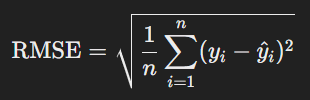

- Cara Kerja
  - RMSE dihitung dengan membandingkan nilai aktual dan nilai prediksi untuk setiap data. Selisih antara nilai aktual dan prediksi kemudian dikuadratkan agar semua nilai positif. Setelah itu, rata-rata dari semua hasil kuadrat dihitung untuk mendapatkan gambaran *error* rata-rata. Terakhir, akar kuadrat dari rata-rata tersebut diambil untuk menghasilkan nilai RMSE.

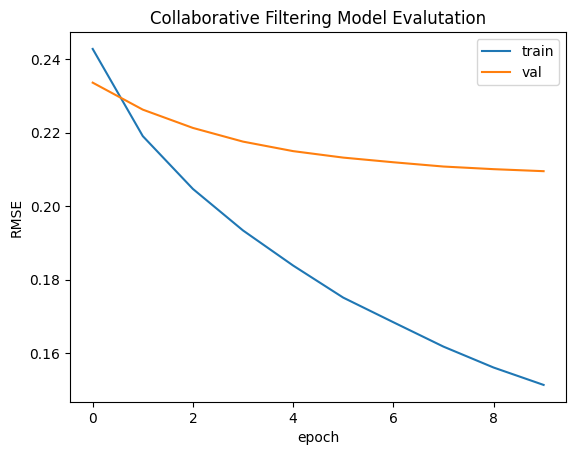

In [ ]:
plt.plot(history.history['root_mean_squared_error'])
plt.plot(history.history['val_root_mean_squared_error'])
plt.title('Collaborative Filtering Model Evalutation')
plt.ylabel('RMSE')
plt.xlabel('epoch')
plt.legend(['train', 'val'])
plt.show()

Berdasarkan *output* kode evaluasi diatas, dapat dilihat bahwa model dengan teknik *collaborative filtering* memberikan kinerja yang cukup baik yang dimana pada setiap *epoch*, RMSE model mengalami penurunan yang cukup signifikan dan terus menurun sampai *epoch* terakhir (10). Pada akhir *epoch*, dapat dilihat bahwa RMSE sudah cukup kecil yang dimana model yang dihasilkan sudah cukup baik. Berikut metrik yang dihasilkan:

- loss: 0.6048
- root_mean_squared_error: 0.1509
- val_loss: 0.6506
- val_root_mean_squared_error: 0.2096

